L = 2, N = 2, dim = 3
init = (1, 1), target = (0, 2)
UPPER_SIDEBAND = True -> f_drive_hz_init = 1120.00 Hz

=== V0_gui = 4  ->  V0 = 2.4 Er  (J_static = 163.491 Hz) ===
   [time init] f=1120.00 Hz -> T_Rabi=34.0954 ms, f_Rabi=29.33 Hz
   [profile init] center=1132.516 Hz, OmegaR=30.397 Hz
   [time final] f=1132.52 Hz -> T_Rabi=34.3177 ms, f_Rabi=29.14 Hz
   [profile final] center=1132.143 Hz, OmegaR=30.264 Hz
   -> Eshift = +12.143 Hz, OmegaR = 30.264 Hz, J_eff = 10.700 Hz

=== V0_gui = 5  ->  V0 = 3 Er  (J_static = 139.120 Hz) ===
   [time init] f=1120.00 Hz -> T_Rabi=32.4673 ms, f_Rabi=30.80 Hz
   [profile init] center=1128.660 Hz, OmegaR=32.006 Hz
   [time final] f=1128.66 Hz -> T_Rabi=32.2948 ms, f_Rabi=30.96 Hz
   [profile final] center=1128.685 Hz, OmegaR=32.520 Hz
   -> Eshift = +8.685 Hz, OmegaR = 32.520 Hz, J_eff = 11.498 Hz

=== V0_gui = 6  ->  V0 = 3.6 Er  (J_static = 118.523 Hz) ===
   [time init] f=1120.00 Hz -> T_Rabi=31.8175 ms, f_Rabi=31.43 Hz
   [profile init] center=1

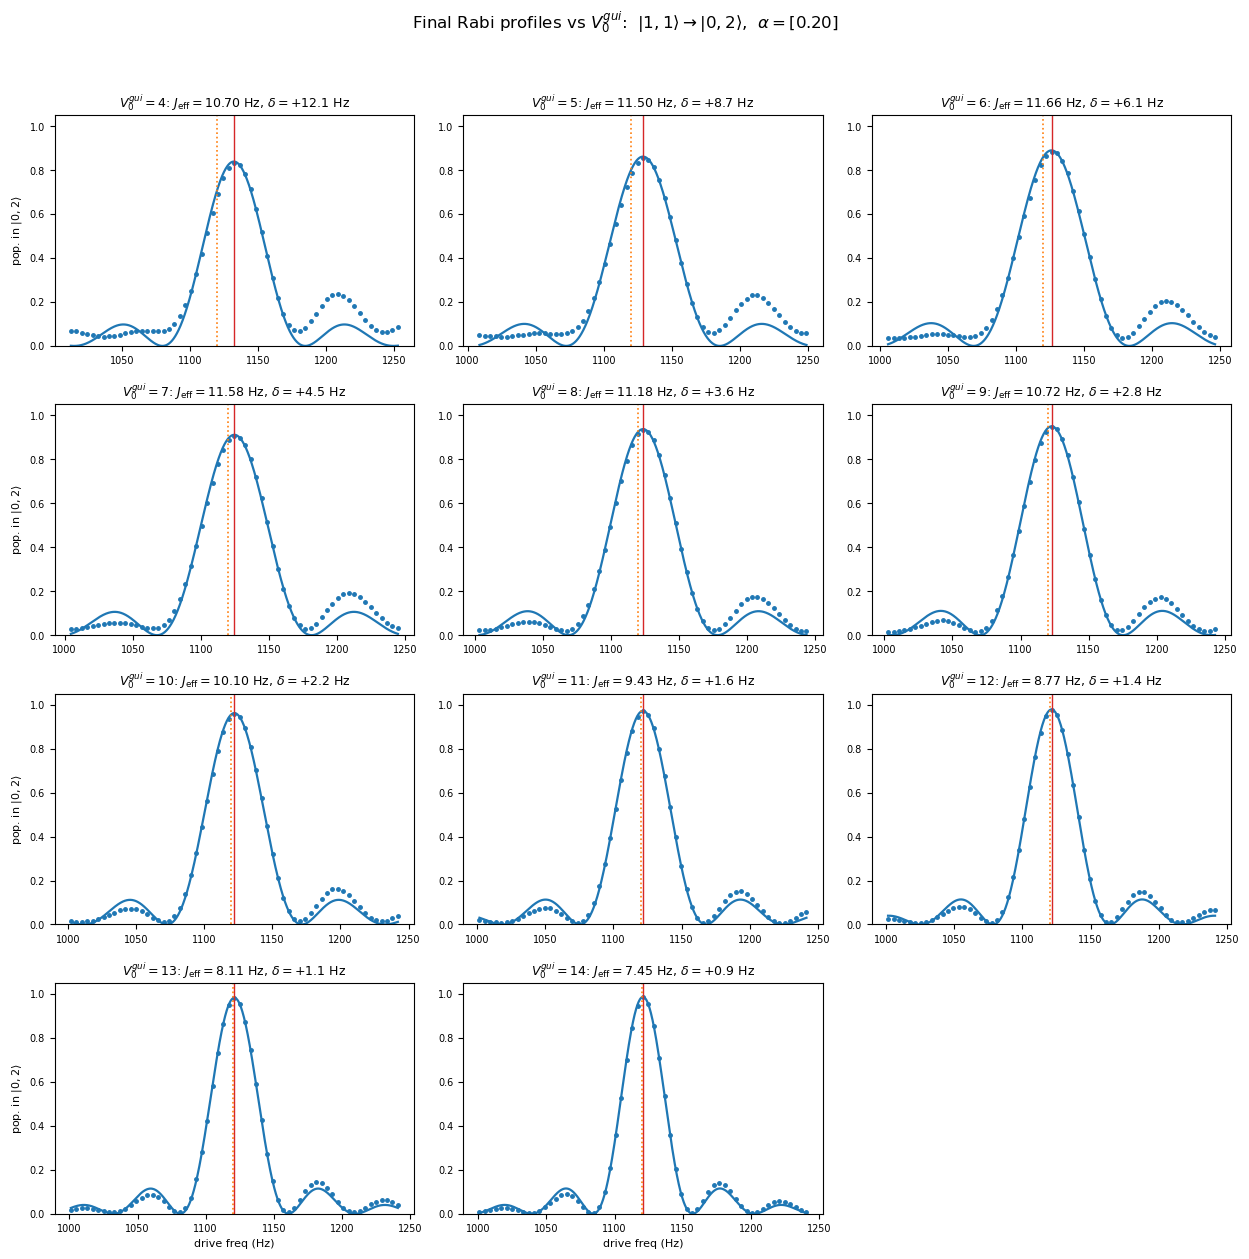

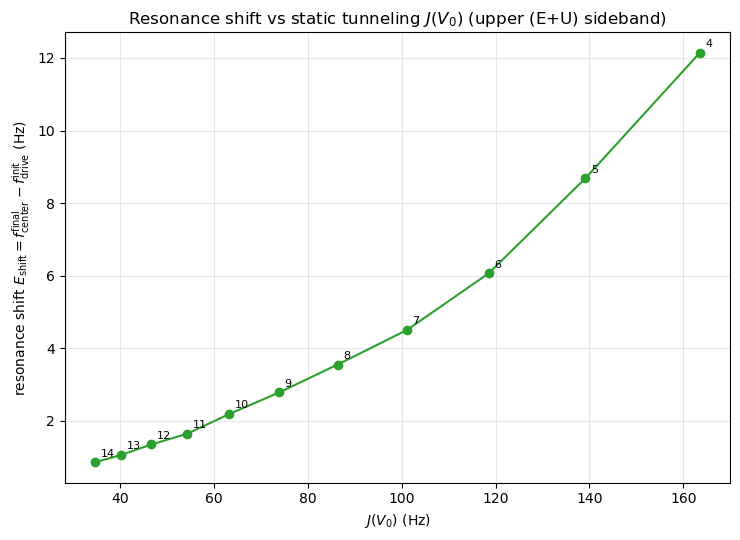


saved -> resonance_Escan_sweep_tiles.png, resonance_Escan_sweep_Eshift.png

 J(V0)_hz, Eshift_hz, V0_gui:
  34.6955  +0.8621  (V0_gui=14)
  40.2127  +1.0621  (V0_gui=13)
  46.6949  +1.3535  (V0_gui=12)
  54.3198  +1.6486  (V0_gui=11)
  63.2982  +2.1930  (V0_gui=10)
  73.8806  +2.7844  (V0_gui=9)
  86.3649  +3.5547  (V0_gui=8)
  101.1055  +4.5050  (V0_gui=7)
  118.5235  +6.0671  (V0_gui=6)
  139.1200  +8.6852  (V0_gui=5)
  163.4912  +12.1431  (V0_gui=4)


In [16]:
# =============================================================
# resonance_Escan_sweep.py
#
# Sweeps the lattice depth V0 (via V0_gui) and, for each value, runs the full
# iterative resonance finder (time scan -> profile fit -> resonant time scan ->
# profile fit) to locate the dressed resonance for a chosen sideband.
#
# Outputs:
#   - a tiled grid of the final Rabi profiles, one tile per V0_gui
#   - a summary plot of the resonance shift Eshift vs the effective tunneling
#     J_eff_hz = OmegaR / (2*sqrt(2))   (sqrt(2) = doublon matrix element)
# =============================================================

import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

# =============================================================
# ============  USER-CHANGEABLE VALUES  =======================
# =============================================================
state_init = [1, 1]          # initial Fock state

Delta_hz   = 835.0           # tilt per site (Hz)
U_hz       = 285.0           # on-site interaction (Hz)

UPPER_SIDEBAND = True        # True  -> f_drive_init = Delta_hz + U_hz, target = (0,2)
                             # False -> f_drive_init = Delta_hz - U_hz, target = (2,0)

# --- V0 sweep ----------------------------------------------------------------
# V0 = 0.75 * 0.8 * V0_gui ; sweep V0_gui from 6 to 11 in steps of 1.
V0_GUI_LIST = np.arange(4, 15, 1)     # 6,7,8,9,10,11

alpha = [0.2]                # depth modulation amplitude(s)

# scan / fit controls
N_PERIODS_PER_RABI = 100     # sets time-trace length (3x this many drive periods)
TIME_SAMPLES_PER_PERIOD = 40

PULSE_SPAN_HZ            = 120.0   # +/- frequency range for the profile scan
PULSE_N_POINTS          = 61
PULSE_SAMPLES_PER_PERIOD = 20
# =============================================================
# ==========  END USER-CHANGEABLE VALUES  =====================
# =============================================================

# --- derive drive frequency and target state from the toggle -----------------
if UPPER_SIDEBAND:
    f_drive_hz_init = Delta_hz + U_hz
    state_target    = [0, 2]
else:
    f_drive_hz_init = Delta_hz - U_hz
    state_target    = [2, 0]

state_init   = list(state_init)
state_target = list(state_target)
if len(state_init) != len(state_target):
    raise ValueError("state_init and state_target must have the same length (L).")
L = len(state_init)
N = sum(state_init)
if sum(state_target) != N:
    raise ValueError("init and target must share particle number N.")

# =============================================================
# LATTICE DEPTH -> TUNNELING CONVERTER
# =============================================================
J_OUTPUT_UNITS = "Hz"
E_R_HZ = 1.0
twopi  = 2.0 * np.pi

def V_to_J(V):
    V = np.asarray(V, dtype=float)
    a = 284.4; b = -0.2922; c = 30.69; d = -0.1304   # Er in, Hz out
    return a * np.exp(b * V) + c * np.exp(d * V)

def J_angular(V):
    Jval = V_to_J(V)
    if J_OUTPUT_UNITS == "Hz":        return twopi * Jval
    elif J_OUTPUT_UNITS == "angular": return Jval
    elif J_OUTPUT_UNITS == "Er":      return twopi * E_R_HZ * Jval
    else: raise ValueError("J_OUTPUT_UNITS must be 'Hz', 'angular', or 'Er'")

# -----------------------------
# Physical parameters in angular units (V0-independent pieces)
# -----------------------------
alpha = np.atleast_1d(np.asarray(alpha, dtype=float))
U     = twopi * U_hz
Delta = twopi * Delta_hz

omega_init = twopi * np.atleast_1d(np.asarray([f_drive_hz_init], dtype=float))
if alpha.shape != omega_init.shape:
    raise ValueError("alpha and the drive-tone list must have the same length.")

# =============================================================
# Fixed-N basis and Hamiltonian (V0-independent)
# =============================================================
def generate_basis(L, N):
    return [tuple(occ) for occ in itertools.product(range(N + 1), repeat=L)
            if sum(occ) == N]

basis = generate_basis(L, N)
index = {s: i for i, s in enumerate(basis)}
dim   = len(basis)
if tuple(state_init) not in index or tuple(state_target) not in index:
    raise ValueError("init/target state not present in the N=%d basis." % N)

print("L = %d, N = %d, dim = %d" % (L, N, dim))
print("init = %s, target = %s" % (tuple(state_init), tuple(state_target)))
print("UPPER_SIDEBAND = %s -> f_drive_hz_init = %.2f Hz" % (UPPER_SIDEBAND, f_drive_hz_init))

def build_diag():
    H = np.zeros((dim, dim), dtype=complex)
    for a, state in enumerate(basis):
        n = np.array(state)
        H[a, a] = 0.5 * U * np.sum(n*(n-1)) + Delta * np.sum(np.arange(L)*n)
    return H

def build_hop_unit():
    H = np.zeros((dim, dim), dtype=complex)
    for a, state in enumerate(basis):
        n = np.array(state)
        for j in range(L-1):
            if n[j] > 0:
                new = n.copy(); amp = np.sqrt(n[j])*np.sqrt(n[j+1]+1)
                new[j]-=1; new[j+1]+=1
                H[index[tuple(new)], a] += -amp
            if n[j+1] > 0:
                new = n.copy(); amp = np.sqrt(n[j+1])*np.sqrt(n[j]+1)
                new[j+1]-=1; new[j]+=1
                H[index[tuple(new)], a] += -amp
    return H

H_diag     = build_diag()
H_hop_unit = build_hop_unit()

# -----------------------------
# State and projector
# -----------------------------
psi0 = np.zeros(dim, dtype=complex)
psi0[index[tuple(state_init)]] = 1.0
P_target = np.zeros((dim, dim), dtype=complex)
P_target[index[tuple(state_target)], index[tuple(state_target)]] = 1.0

# =============================================================
# Evolution and fit helpers (take V0 as an explicit argument)
# =============================================================
def V_of_t(t, om, V0):
    return V0 * (1.0 + np.sum(alpha * np.cos(om * t)))

def evolve(n_periods, samples_per_period, om, V0, t_end=None):
    T_ref_local = 1.0 / (om.min() / twopi)
    if t_end is None:
        t_end = n_periods * T_ref_local
        ntimes = n_periods * samples_per_period + 1
    else:
        n_per = max(1, int(round(t_end / T_ref_local)))
        ntimes = n_per * samples_per_period + 1
    def rhs(t, psi):
        Jt = J_angular(V_of_t(t, om, V0))
        return -1j * (H_diag + Jt * H_hop_unit).dot(psi)
    times = np.linspace(0.0, t_end, ntimes)
    sol = solve_ivp(rhs, (0.0, t_end), psi0, t_eval=times,
                    rtol=1e-9, atol=1e-9, method="RK45")
    return times, sol.y.T

def rabi_model(t, A, T_rabi, offset):
    return offset + 0.5 * A * (1.0 - np.cos(2.0 * np.pi * t / T_rabi))

def ket(s):
    return r"|%s\rangle" % ",".join(str(x) for x in s)

def fit_time_trace(f_drive_hz, V0, label=""):
    om = twopi * np.array([f_drive_hz])
    n_periods = 3 * N_PERIODS_PER_RABI
    times, psis = evolve(n_periods, TIME_SAMPLES_PER_PERIOD, om=om, V0=V0)
    ptar = np.array([np.vdot(p, P_target.dot(p)).real for p in psis])

    w = TIME_SAMPLES_PER_PERIOD
    kernel = np.ones(w) / w
    ptar_avg = np.convolve(ptar, kernel, mode="valid")
    t_avg    = times[(w-1)//2 : (w-1)//2 + len(ptar_avg)]

    sig = ptar_avg - ptar_avg.mean()
    dt  = t_avg[1] - t_avg[0]
    freqs_fft = np.fft.rfftfreq(len(sig), d=dt)
    power = np.abs(np.fft.rfft(sig)); power[0] = 0.0
    f_dom = freqs_fft[np.argmax(power)]
    T_guess = 1.0 / f_dom if f_dom > 0 else (t_avg[-1] - t_avg[0])
    p0 = [ptar_avg.max() - ptar_avg.min(), T_guess, ptar_avg.min()]
    try:
        popt, pcov = curve_fit(rabi_model, t_avg, ptar_avg, p0=p0, maxfev=20000)
        T_fit = popt[1]
        print("   [time %s] f=%.2f Hz -> T_Rabi=%.4f ms, f_Rabi=%.2f Hz"
              % (label, f_drive_hz, 1000*T_fit, 1.0/T_fit))
    except RuntimeError:
        popt = p0; T_fit = T_guess
        print("   [time %s] fit failed; FFT guess T=%.4f ms" % (label, 1000*T_fit))
    return T_fit

def pulse_lineshape(x, A, OmegaR, x0):
    gen = np.sqrt(OmegaR**2 + (x - x0)**2)
    lor = OmegaR**2 / (OmegaR**2 + (x - x0)**2)
    return A * lor * np.sin(np.pi * gen / (2.0 * OmegaR))**2

def pulsed_population(f_drive, t_pi, V0):
    om = twopi * np.array([f_drive])
    tt, pp = evolve(None, PULSE_SAMPLES_PER_PERIOD, om=om, V0=V0, t_end=t_pi)
    pj = np.array([np.vdot(p, P_target.dot(p)).real for p in pp])
    T_drive = 1.0 / f_drive
    n_final = max(1, int(round((tt[-1] - tt[0]) / T_drive)))
    wloc = max(1, len(tt) // max(1, n_final))
    if wloc < len(pj):
        kloc = np.ones(wloc) / wloc
        return np.convolve(pj, kloc, mode="valid")[-1]
    return pj.mean()

def fit_profile(f_center_guess, t_pi, T_fit, V0, label=""):
    scan_freqs = np.linspace(f_center_guess - PULSE_SPAN_HZ,
                             f_center_guess + PULSE_SPAN_HZ, PULSE_N_POINTS)
    pulse_pop = np.array([pulsed_population(f, t_pi, V0) for f in scan_freqs])
    f_peak = scan_freqs[np.argmax(pulse_pop)]

    OmegaR_guess = 1.0 / T_fit
    p0_line = [pulse_pop.max(), OmegaR_guess, f_peak]
    try:
        popt_line, _ = curve_fit(pulse_lineshape, scan_freqs, pulse_pop,
                                 p0=p0_line, maxfev=40000)
        popt_line[1] = abs(popt_line[1])
        x0 = popt_line[2]
        fit_ok = True
        print("   [profile %s] center=%.3f Hz, OmegaR=%.3f Hz"
              % (label, x0, popt_line[1]))
    except RuntimeError:
        popt_line = p0_line; x0 = f_peak; fit_ok = False
        print("   [profile %s] fit failed; peak=%.3f Hz" % (label, f_peak))
    return scan_freqs, pulse_pop, popt_line, x0, fit_ok

# =============================================================
# FULL ITERATIVE RESONANCE FINDER FOR ONE V0
# =============================================================
def run_resonance(V0):
    # STEP 2: preliminary time scan
    T_rabi_init = fit_time_trace(f_drive_hz_init, V0, label="init")
    # STEP 3: profile scan
    t_pi_init = 0.5 * T_rabi_init
    _, _, _, f_center_rabi_init, _ = fit_profile(
        f_drive_hz_init, t_pi_init, T_rabi_init, V0, label="init")
    # STEP 4: resonant time scan
    T_rabi_final = fit_time_trace(f_center_rabi_init, V0, label="final")
    # STEP 5: profile scan with resonant pi-pulse
    t_pi_final = 0.5 * T_rabi_final
    sf_f, pp_f, popt_l_fin, f_center_rabi_final, ok_l_fin = fit_profile(
        f_center_rabi_init, t_pi_final, T_rabi_final, V0, label="final")

    OmegaR_final = popt_l_fin[1]
    Eshift       = f_center_rabi_final - f_drive_hz_init
    # effective tunneling from the doublon Rabi coupling: OmegaR = 2*sqrt(2)*J_eff
    J_eff_hz     = OmegaR_final / (2.0 * np.sqrt(2.0))

    return dict(V0=V0,
                J_static_hz=J_angular(V0)/twopi,
                scan_freqs=sf_f, pulse_pop=pp_f, popt_line=popt_l_fin,
                f_center=f_center_rabi_final, line_fit_ok=ok_l_fin,
                T_rabi_final=T_rabi_final, t_pi_final=t_pi_final,
                OmegaR=OmegaR_final, Eshift=Eshift, J_eff_hz=J_eff_hz)

# =============================================================
# RUN THE SWEEP
# =============================================================
results = []
for V0_gui in V0_GUI_LIST:
    V0 = 0.75 * 0.8 * V0_gui
    print("\n=== V0_gui = %g  ->  V0 = %.4g Er  (J_static = %.3f Hz) ==="
          % (V0_gui, V0, J_angular(V0)/twopi))
    res = run_resonance(V0)
    res["V0_gui"] = V0_gui
    results.append(res)
    print("   -> Eshift = %+.3f Hz, OmegaR = %.3f Hz, J_eff = %.3f Hz"
          % (res["Eshift"], res["OmegaR"], res["J_eff_hz"]))

amp_str = ", ".join("%.2f" % a for a in alpha)

# =============================================================
# TILED PLOT: final Rabi profile per V0_gui
# =============================================================
n = len(results)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.2*nrows),
                         squeeze=False)
for k, res in enumerate(results):
    ax = axes[k // ncols][k % ncols]
    ax.plot(res["scan_freqs"], res["pulse_pop"], "o", color="C0", ms=2.5,
            label="sim")
    if res["line_fit_ok"]:
        xfine = np.linspace(res["scan_freqs"][0], res["scan_freqs"][-1], 800)
        ax.plot(xfine, pulse_lineshape(xfine, *res["popt_line"]), "-",
                color="C0", lw=1.6)
    ax.axvline(res["f_center"], color="C3", ls="-", lw=1.0)
    ax.axvline(f_drive_hz_init, color="C1", ls=":", lw=1.2)
    ax.set_title(r"$V_0^{gui}=%g$: $J_\mathrm{eff}=%.2f$ Hz, $\delta=%+.1f$ Hz"
                 % (res["V0_gui"], res["J_eff_hz"], res["Eshift"]), fontsize=9)
    ax.set_ylim(0, 1.05)
    if k // ncols == nrows - 1:
        ax.set_xlabel("drive freq (Hz)", fontsize=8)
    if k % ncols == 0:
        ax.set_ylabel(r"pop. in $%s$" % ket(state_target), fontsize=8)
    ax.tick_params(labelsize=7)

# hide any unused tiles
for k in range(n, nrows*ncols):
    axes[k // ncols][k % ncols].axis("off")

fig.suptitle(r"Final Rabi profiles vs $V_0^{gui}$:  $%s\to%s$,  $\alpha=[%s]$"
             % (ket(state_init), ket(state_target), amp_str), fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig("resonance_Escan_sweep_tiles.png", dpi=120)
plt.show()

# =============================================================
# SUMMARY PLOT: Eshift vs static J(V0)
# =============================================================
J_static_arr = np.array([r["J_static_hz"] for r in results])
Eshift_arr   = np.array([r["Eshift"]      for r in results])
order = np.argsort(J_static_arr)
J_static_arr = J_static_arr[order]
Eshift_arr   = Eshift_arr[order]

plt.figure(figsize=(7.5, 5.5))
plt.plot(J_static_arr, Eshift_arr, "o-", color="C2", ms=6)
for r in results:
    plt.annotate("%g" % r["V0_gui"],
                 xy=(r["J_static_hz"], r["Eshift"]),
                 xytext=(4, 4), textcoords="offset points", fontsize=8)
plt.xlabel(r"$J(V_0)$ (Hz)")
plt.ylabel(r"resonance shift $E_\mathrm{shift}=f_\mathrm{center}^\mathrm{final}-f_\mathrm{drive}^\mathrm{init}$ (Hz)")
side = "upper (E+U)" if UPPER_SIDEBAND else "lower (E-U)"
plt.title(r"Resonance shift vs static tunneling $J(V_0)$ (%s sideband)" % side)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("resonance_Escan_sweep_Eshift.png", dpi=120)
plt.show()

print("\nsaved -> resonance_Escan_sweep_tiles.png, resonance_Escan_sweep_Eshift.png")
print("\n J(V0)_hz, Eshift_hz, V0_gui:")
for r in sorted(results, key=lambda d: d["J_static_hz"]):
    print("  %.4f  %+.4f  (V0_gui=%g)" % (r["J_static_hz"], r["Eshift"], r["V0_gui"]))